In [1]:
# Setup LangSmith
from dotenv import load_dotenv

load_dotenv()

True

# Basic idea
Use LangGraph to create an AI chatbot that can answer questions about myself.

# Basic pipeline
1. Recieve query from user.
2. LLM first decides whether a query is about Tim Forrer or not.
3. If yes, use a retriever tool to get the necessary context needed to answer the question.
4. If no, come up with an answer to the question.
    - Prompt allows the LLM to say that it doesn't know.
    - If it doesn't know, use a web query to retrieve additional context.
5. Generate a final answer.
6. Output this answer.

---
# References
https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_agentic_rag/#retriever

# Setup

In [2]:
from langchain_ollama import ChatOllama

# Setup the base LLM
LLM_MODEL = "llama3.2"
base_llm = ChatOllama(
    model=LLM_MODEL,
    temperature=0,
    streaming=True  # allows for streaming of LLM response
)

# Setup the embedding model.
from langchain_huggingface import HuggingFaceEmbeddings
EMBEDDING_MODEL = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

# Setup vector database
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.vectorstores import FAISS

DOCS_DIR = "./docs"

loader = DirectoryLoader(DOCS_DIR)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=100
)

docs = loader.load()
all_splits = text_splitter.split_documents(docs)
vector_store = FAISS.from_documents(
    documents=all_splits,
    embedding=embeddings,
)

# State

In [3]:
from typing import Annotated, Sequence, Optional
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langchain_core.documents import Document

from langgraph.graph.message import add_messages

# Define the AgentState
class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    # The list of messages is the state that is passed through the graph
    query: str
    rag_query: Optional[str]
    messages: Annotated[Sequence[BaseMessage], add_messages]
    context: list[Document]
    answer: str

# Util Functions

In [4]:
# Util functions
from langchain_core.messages import HumanMessage

def get_last_message_of_type(state: AgentState, message_type: type[BaseMessage]) -> Optional[BaseMessage]:
    """Get the most recent message of type `message_type`.
    """
    for msg in state["messages"][::-1]:
        if isinstance(msg, message_type):
            return msg
    return

def get_last_human_message(state: AgentState) -> Optional[HumanMessage]:
    """Get the most recent human message.
    """
    return get_last_message_of_type(state, HumanMessage)

def get_last_message(state: AgentState) -> BaseMessage:
    """Get the most recently added message to the AgentState.
    """
    return state["messages"][-1]

# Schemas

In [5]:
from pydantic import BaseModel, Field
from typing import Literal

class BinaryGrader(BaseModel):
    """Always use this to structure your response: either 'yes' or 'no'."""
    grade: Literal["yes", "no"] = Field(description="Your response, 'yes' or 'no'.")

# Nodes

In [ ]:
from langchain_core.prompts import PromptTemplate

def related_to_tim(state: AgentState) -> Literal["generate", "retrieve"]:
    """Decide whether the user query is relevant to Tim Forrer or not.
    """
    prompt = PromptTemplate.from_template(
        """
        You are an LLM that determines if a user query is related to Tim Forrer.

        A query is considered related to Tim Forrer if it:
        1. Contains the name "Tim", "Forrer", or "Tim Forrer" (case-insensitive)
        2. Uses personal pronouns (he/him/his) that refer to Tim Forrer based on context 
        3. Asks about Tim's personal information, preferences, history, or activities
        4. References something previously established about Tim Forrer in the message history

        IMPORTANT: Any direct mention of Tim Forrer by name, even in passing, should be classified as related to him.

        Examples of queries about Tim Forrer:
        - "What does Tim like to do on weekends?"
        - "Where did Forrer go to school?"
        - "Did he mention his favorite book in our previous conversation?"
        - "Can you tell me about his background?"
        - "What programming languages does Tim know?"

        If the query is related to Tim Forrer in ANY way: respond with 'yes'
        If the query is clearly unrelated or you're unsure: respond with 'no'

        User query: {user_query}
        Message history: {messages}
        """)

    relevance_grader = prompt | base_llm.with_structured_output(BinaryGrader)
    relevance_grade = relevance_grader.invoke({
        "user_query": state["query"],
        "messages": state["messages"]
    })

    print("Relevance grade:", relevance_grade.grade)

    if relevance_grade.grade == "no":
        return "generate"
    else:
        return "retrieve"

def retrieve(state: AgentState) -> dict[str, str]:
    """
    Query the vector database for relevant documents to the user query.
    
    Uses the rewritten query if it is available, else use the user query.
    """
    retriever = vector_store.as_retriever(
        search_kwargs={"k": 3}
    )
    print(state["rag_query"])
    if state["rag_query"] is None:
        state["rag_query"] = state["query"]
    docs = retriever.invoke(state["rag_query"])
    
    return {"context": docs}

def document_grader(state: AgentState) -> Literal["generate", "rewrite"]:
    """Decide whether retrieved documents are relevant to the user query or not.
    """
    prompt = PromptTemplate.from_template(
        """
        You are an LLM that decides if retrieved documents are relevant to a given user query.
        If you determine that the documents contain the answer to the user query, return an answer of 'yes'.
        Otherwise (including if you are not sure), respond with 'no'.

        User query: {user_query}
        Documents: {docs}
        """)
    document_grader = prompt | base_llm.with_structured_output(BinaryGrader)

    user_query = get_last_human_message(state)
    docs = get_last_message(state)
    document_grade = document_grader.invoke({
        "user_query": user_query,
        "docs": docs
    })

    print("Document grade:", document_grade.grade)

    if document_grade.grade == "yes":
        return "generate"
    else:
        return "rewrite"

    
def rewrite(state: AgentState) -> dict[str, str]:
    """Rewrite the user query so that it is more appropriate for RAG.
    """
    prompt = PromptTemplate.from_template(
        """You are an expert at rewriting user queries so that they are suitable for retrieving information from a vector database.
        Given a user query, choose the keywords/phrases that will best retrieve relevant documents from a vector database containing information about a person called Tim Forrer, and return your rewritten query including these keywords/phrases.

        User query: {user_query}
        """)
    rewriter = prompt | base_llm

    rewritten_query = rewriter.invoke({
        "user_query": state["query"]
    })
    return {"rag_query": rewritten_query.content}

def generate(state: AgentState) -> dict[str, str]:
    """Generate an answer to the user query.
    """
    prompt = PromptTemplate.from_template(
        """
        You are an assistant for question-answering tasks.
        Answer the given question below as best you can.
        If you need to, use the additional pieces of retrieved context to answer the question.
        If you don't know the answer, just say that you don't know.
        Use three sentences maximum and keep the answer concise.

        Question: {question}

        Context: {context}
        """
    )
    generator = prompt | base_llm
    response = generator.invoke({
        "question": state["query"],
        "context": state["context"]
    })

    return {"messages": response, "answer": response.content}

# Build Graph

In [7]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import tools_condition

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

# Add edges
workflow.add_conditional_edges(
    START,
    related_to_tim
)
workflow.add_conditional_edges(
    "retrieve",
    document_grader
)
workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("generate", END)

graph = workflow.compile()

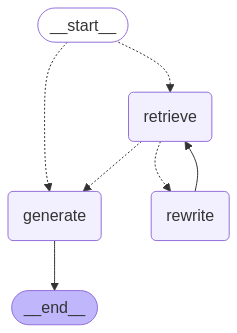

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(Image(graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API,
)))

In [10]:
query = "Where did Tim Forrer go to university?"

inputs = {
    "query": query,
    "messages": [
        ("user", query),
    ],
    "rag_query": None,
    "context": None
}
for output in graph.stream(inputs):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("---")
        print(value)
    print("---")

Relevance grade: yes
None
Document grade: yes
Output from node 'retrieve':
---
{'context': [Document(id='06faf37e-036a-45d6-a1ff-82e593c0e5ba', metadata={'source': 'docs/FORRER-CV_3.docx'}, page_content='CV\n\nTim Forrer\n\ntim.d.forrer@gmail.com | +81 (0) 80 9405 7118\n\nSUMMARY\n\nDoctoral student specializing in theoretical physics, with a strong foundation in mathematical modeling, extensive research experience, and excellent communication skills. Eager for opportunities to apply expertise to apply skills whilst staying at the forefront of technological innovation.\n\nEDUCATION\n\nPhysics PhD - University of Tokyo, Japan\tOct 2022 - Present'), Document(id='1dfe1f96-9e64-4626-bae5-df2ef93b6b9e', metadata={'source': 'docs/FORRER-CV_0.docx'}, page_content='CV\n\nTim Forrer\n\ntim.d.forrer@gmail.com | +81 (0) 80 9405 7118\n\nSUMMARY\n\nDoctoral student with a history of high achievement, proven long-term enthusiasm for technology, and a strong team-oriented approach. Excited to pursue 